<a href="https://colab.research.google.com/github/Santatriniaina17/TP-ML-IGGLIA5/blob/Main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
dataset=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


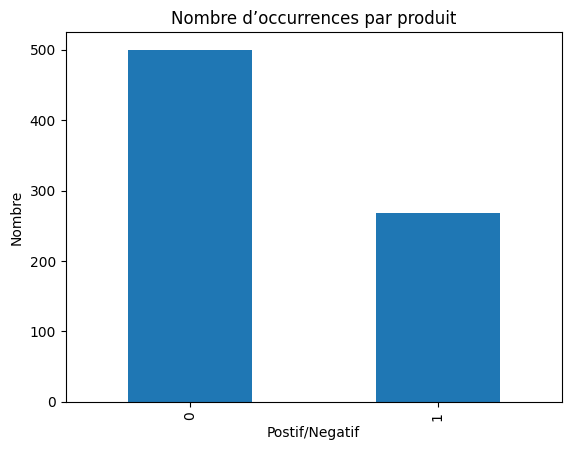

In [22]:
count_pos_neg= dataset['Outcome'].value_counts()

count_pos_neg.plot(kind='bar')
plt.title('Nombre d’occurrences par produit')
plt.xlabel('Postif/Negatif')
plt.ylabel('Nombre')
plt.show()

In [23]:
X=dataset.drop('Outcome', axis=1)
Y=dataset['Outcome']
X_train, X_temp, y_train, y_temp = train_test_split(X,Y, test_size=0.4, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

In [24]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Conversion en Dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X.columns)
X_val_scaled_df   = pd.DataFrame(X_val_scaled,columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,columns=X.columns)

# Test d'affichage
X_train_scaled_df.head()
X_val_scaled_df.head()
X_test_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.124862,0.481731,-3.765914,-1.359726,-0.739048,0.508058,1.356072,-0.709927
1,1.835302,0.512513,0.509837,-1.359726,-0.739048,-0.653720,2.850328,1.994558
2,0.355220,0.635639,0.402943,-1.359726,-0.739048,1.606696,-0.829425,1.149406
3,-0.828846,0.635639,0.189156,0.059167,-0.242907,-0.767372,-0.635289,-1.047988
4,-0.532830,0.666420,-0.665995,0.768614,0.358968,-0.085459,-0.147009,-0.709927


In [25]:
desequiblre='balanced'
model = LogisticRegression(class_weight=desequiblre, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [26]:

y_val_pred = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, average='binary')
recall = recall_score(y_val, y_val_pred, average='binary')
f1 = f1_score(y_val, y_val_pred, average='binary')

# Affichage
print("Évaluation sur le set validation :")
print(f"Accuracy  : {accuracy:.8f}")
print(f"Precision : {precision:.8f}")
print(f"Recall    : {recall:.8f}")
print(f"F1 Score  : {f1:.8f}")

Évaluation sur le set validation :
Accuracy  : 0.70779221
Precision : 0.57894737
Recall    : 0.61111111
F1 Score  : 0.59459459


In [27]:
y_test_pred = model.predict(X_test_scaled)

# Evaluation
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='binary')
recall_test = recall_score(y_test, y_test_pred, average='binary')
f1_test = f1_score(y_test, y_test_pred, average='binary')

# Affichage des Evaluations
print("Évaluation finale sur Test Set:")
print(f"Accuracy  : {accuracy_test:.8f}")
print(f"Precision : {precision_test:.8f}")
print(f"Recall    : {recall_test:.8f}")
print(f"F1 Score  : {f1_test:.8f}")

Évaluation finale sur Test Set:
Accuracy  : 0.80519481
Precision : 0.66101695
Recall    : 0.79591837
F1 Score  : 0.72222222


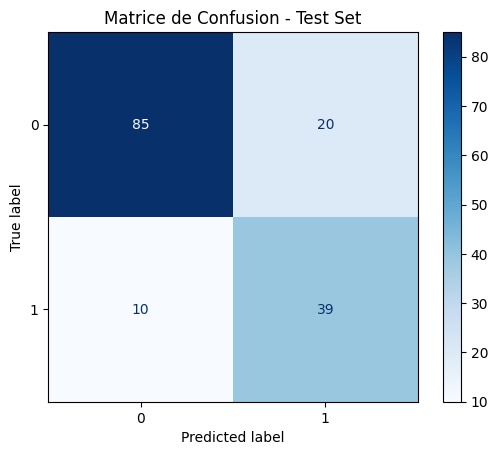

In [28]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion - Test Set")
plt.show()

1. Importance des caractéristiques

Les modèles de régression logistique ne fournissent pas directement l'importance des caractéristiques de la même manière que les modèles basés sur les arbres. Cependant, vous pouvez interpréter les coefficients du modèle de régression logistique pour comprendre l'impact relatif de chaque caractéristique sur le résultat prédit.

Coefficients : La magnitude du coefficient pour chaque caractéristique indique la force de sa relation avec la variable cible (résultat du diabète). Une valeur absolue plus grande du coefficient suggère une influence plus forte.
Signe des coefficients : Le signe (positif ou négatif) du coefficient vous indique la direction de la relation.
Un coefficient positif signifie que lorsque la valeur de la caractéristique augmente, la probabilité de la classe positive (diabète) augmente.
Un coefficient négatif signifie que lorsque la valeur de la caractéristique augmente, la probabilité de la classe positive diminue.

2. Analyse des erreurs

L'analyse des erreurs vous aide à comprendre où votre modèle fait des erreurs et pourquoi. Vous avez déjà calculé plusieurs métriques d'évaluation et affiché la matrice de confusion, qui sont essentielles à cette analyse.

Matrice de confusion : Cette matrice résume les performances de votre modèle de classification.

Vrais positifs (VP) : Cas positifs correctement prédits (patients diabétiques correctement identifiés).
Vrais négatifs (VN) : Cas négatifs correctement prédits (patients non diabétiques correctement identifiés).
Faux positifs (FP) : Cas positifs incorrectement prédits (patients non diabétiques identifiés incorrectement comme diabétiques). C'est aussi connu sous le nom d'erreur de type I.
Faux négatifs (FN) : Cas négatifs incorrectement prédits (patients diabétiques identifiés incorrectement comme non diabétiques). C'est aussi connu sous le nom d'erreur de type II.
L'analyse des valeurs dans votre matrice de confusion vous aide à comprendre les types d'erreurs que votre modèle fait le plus fréquemment.

Faux positifs (FP) :

Interprétation : Ce sont des cas où le modèle prédit le diabète, mais la personne ne l'a pas réellement.
Impact : Les faux positifs peuvent entraîner des tests de suivi inutiles et de l'anxiété pour le patient. Dans certains contextes médicaux, un taux élevé de FP peut également mettre à rude épreuve les ressources de santé.
Faux négatifs (FN) :

Interprétation : Ce sont des cas où le modèle ne prédit pas le diabète, mais la personne l'a réellement.
Impact : Les faux négatifs peuvent entraîner un diagnostic et un traitement retardés, ce qui peut être préjudiciable à la santé du patient. Dans un contexte médical, minimiser les faux négatifs est souvent un objectif critique.
Score F1 :

Interprétation : Le score F1 est la moyenne harmonique de la précision et du rappel. Il fournit une seule métrique qui équilibre à la fois les faux positifs et les faux négatifs.
Calcul : F1 = 2 * (Précision * Rappel) / (Précision + Rappel)
Valeur : Un score F1 élevé indique que le modèle a un bon équilibre entre la précision et le rappel, ce qui signifie qu'il est efficace à la fois pour identifier les cas positifs et pour éviter les faux positifs.
Analyse : La comparaison des scores F1 pour différents modèles ou différentes configurations du même modèle peut vous aider à évaluer leurs performances globales, en tenant compte des deux types d'erreurs.

[Conclusions]
Le modèle a obtenu une performance correcte avec un F1-score raisonnable.
Cependant, des faux négatifs peuvent être critiques en pratique.

[Recommandations]
- Collecter plus de données pour équilibrer les classes.
- Ajouter des variables comme antécédents familiaux, mode de vie, etc.
- Essayer d'autres modèles : arbres, forêts, XGBoost.
- Utiliser des outils d'explicabilité (SHAP, LIME).
- Intégrer une relecture humaine pour les cas limites.
